In [1]:
import gym
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def show_animation(imgs):
    rc("animation", html="jshtml")
    fig, ax = plt.subplots(1, 1, figsize=(5, 3))
    frames = []

    text = ax.text(10, 20, "", fontsize=12, color="black")

    for i, img in enumerate(imgs):
        frame = [ax.imshow(img, animated=True)]
        frame.append(ax.text(10, 20, f"Step: {i + 1}", animated=True))  # Step数表示
        frames.append(frame)

    ax.axis("off")

    ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

    # 保存动画
    # ani.save("cartpole.mp4", writer="ffmpeg")
    ani.save("cartpole.gif", writer="pillow")

    plt.close(fig)
    return ani


def plot_loss(episode_list, return_list, filename):
    """绘制奖励图像"""
    f = plt.figure()
    plt.plot(episode_list, return_list)
    plt.xlabel("Episodes")
    plt.ylabel("Returns")
    plt.title("CartPole-v0")
    plt.show()
    f.savefig(filename, bbox_inches="tight")


class PolicyNet(nn.Module):
    """策略神经网络的结构"""

    def __init__(self, action_size):
        super().__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):  # x是S_t
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim=1)
        return x


class Agent:
    def __init__(self):
        self.gamma = 0.98  # 折扣因子γ
        self.lr = 0.0002  # 学习率α
        self.action_size = 2  # 两个动作：向左推和向右推
        # 初始化策略网络π_θ
        self.pi = PolicyNet(self.action_size)
        self.optimizer = optim.Adam(
            self.pi.parameters(),
            lr=self.lr
        )

    def get_action(self, state):
        """输入参数：环境的状态"""
        # 动作的概率分布
        probs = self.pi(torch.tensor(state).unsqueeze(0)).squeeze(0)
        # 创建一个二项分布采样器
        m = Categorical(probs)
        # 采样一个动作
        action = m.sample().item()

        return action, probs

    def collect_trajectory(self, env):
        """在环境env中采样一条轨迹"""
        state = env.reset()
        states, actions, rewards = [], [], []
        done = False

        while not done:
            # 采取动作A_t
            action, _ = self.get_action(state)
            # 执行动作A_t
            next_state, reward, done, _ = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            # 状态转移
            state = next_state
        # states: [S_0, S_1, S_2, ..., S_T]
        # actions: [A_0, A_1, A_2, ..., A_T]
        # rewards: [R_0, R_1, R_2, ..., R_T]
        return states, actions, rewards

    def update(self, trajectory):
        """用轨迹trajectory数据更新策略网络"""
        states, actions, rewards = trajectory
        # 逆序计算G(τ)
        G = 0
        for r in rewards[::-1]:
            G = r + self.gamma * G
        # 计算损失
        states = torch.tensor(states)
        actions = torch.tensor(actions).view(-1, 1)
        log_probs = torch.log(self.pi(states).gather(1, actions))
        loss = -torch.sum(log_probs) * G

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\utils\passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for 

回合：0, 总奖励：18.0
回合：100, 总奖励：9.0
回合：200, 总奖励：38.0
回合：300, 总奖励：40.0
回合：400, 总奖励：15.0
回合：500, 总奖励：16.0
回合：600, 总奖励：48.0
回合：700, 总奖励：70.0
回合：800, 总奖励：38.0
回合：900, 总奖励：42.0
回合：1000, 总奖励：30.0
回合：1100, 总奖励：18.0
回合：1200, 总奖励：25.0
回合：1300, 总奖励：39.0
回合：1400, 总奖励：115.0
回合：1500, 总奖励：62.0
回合：1600, 总奖励：19.0
回合：1700, 总奖励：34.0
回合：1800, 总奖励：42.0
回合：1900, 总奖励：76.0
回合：2000, 总奖励：43.0
回合：2100, 总奖励：31.0
回合：2200, 总奖励：50.0
回合：2300, 总奖励：64.0
回合：2400, 总奖励：84.0
回合：2500, 总奖励：49.0
回合：2600, 总奖励：28.0
回合：2700, 总奖励：17.0
回合：2800, 总奖励：79.0
回合：2900, 总奖励：24.0


C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


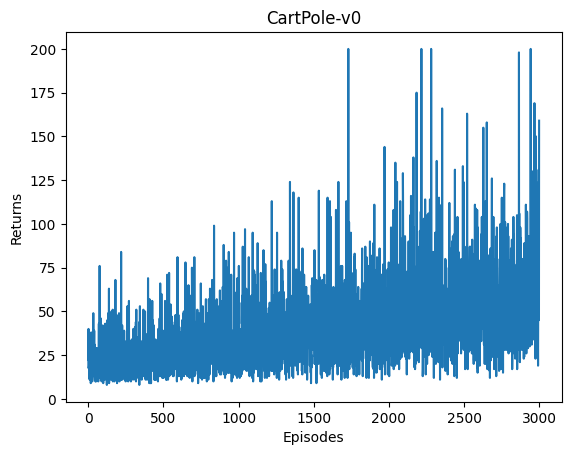

In [3]:
env = gym.make("CartPole-v0")
agent = Agent()
return_list = []
episode_list = []

for episode in range(3000):
    # 采样一条轨迹
    trajectory = agent.collect_trajectory(env)
    # 使用采样到的轨迹更新策略
    agent.update(trajectory)

    # 统计数据
    rewards = trajectory[2]
    return_list.append(sum(rewards))
    episode_list.append(episode)

    if episode % 100 == 0:
        print("回合：{}, 总奖励：{:.1f}".format(episode, sum(rewards)))

# 可视化损失
plot_loss(episode_list, return_list, "pg-loss.pdf")

In [4]:
def test_agent(agent, env):
    """测试训练后的智能体"""
    state = env.reset()
    done = False
    frames = []

    while not done:
        frames.append(env.render(mode="rgb_array"))
        action, _ = agent.get_action(state)
        next_state, _, done, _ = env.step(action)
        state = next_state

    env.close()
    show_animation(frames)


test_agent(agent, env)

C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\gym\core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
C:\MySoftware\Anaconda3\envs\python311\Lib\site-packages\pkg_resources\__init__.py:3146: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.